<a href="https://colab.research.google.com/github/Cayzoxs/UAS-TA-Machine-Learning/blob/main/notebooks/02_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install shap xgboost imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import shap

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Load Data
url = "https://raw.githubusercontent.com/Cayzoxs/UAS-TA-Machine-Learning/main/data/raw/data.csv"
df = pd.read_csv(url, sep=';')
df = df[df['Target'] != 'Enrolled'] # Fokus biner

X = df.drop('Target', axis=1)
y = df['Target']

# Encoding & Scaling
le = LabelEncoder()
y_encoded = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Export Preprocessing objects (untuk dipakai di Streamlit)
with open('preprocessing.pkl', 'wb') as f:
    pickle.dump({'scaler': scaler, 'label_encoder': le, 'fitur_kolom': X.columns.tolist()}, f)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
print("Data latih siap. Pipeline preprocessing telah disimpan sebagai 'preprocessing.pkl'")

Data latih siap. Pipeline preprocessing telah disimpan sebagai 'preprocessing.pkl'


In [3]:
print("Sebelum SMOTE - Distribusi Target Latih:", np.bincount(y_train))

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Sesudah SMOTE - Distribusi Target Latih:", np.bincount(y_train_smote))

Sebelum SMOTE - Distribusi Target Latih: [1137 1767]
Sesudah SMOTE - Distribusi Target Latih: [1767 1767]


In [4]:
# 1. Random Forest (Model Pembanding)
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_smote, y_train_smote)
rf_pred = rf.predict(X_test)

# 2. XGBoost dengan Hyperparameter Tuning
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}

grid_xgb = GridSearchCV(xgb, param_grid, cv=3, scoring='recall', n_jobs=-1)
grid_xgb.fit(X_train_smote, y_train_smote)

best_xgb = grid_xgb.best_estimator_
xgb_pred = best_xgb.predict(X_test)

print("Proses Training Selesai!")
print("Parameter XGBoost Terbaik:", grid_xgb.best_params_)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:17:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Proses Training Selesai!
Parameter XGBoost Terbaik: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}


=== Performa Random Forest ===
              precision    recall  f1-score   support

     Dropout       0.94      0.83      0.88       284
    Graduate       0.90      0.96      0.93       442

    accuracy                           0.91       726
   macro avg       0.92      0.90      0.91       726
weighted avg       0.91      0.91      0.91       726


=== Performa XGBoost (Terbaik) ===
              precision    recall  f1-score   support

     Dropout       0.93      0.82      0.87       284
    Graduate       0.89      0.96      0.92       442

    accuracy                           0.90       726
   macro avg       0.91      0.89      0.90       726
weighted avg       0.91      0.90      0.90       726



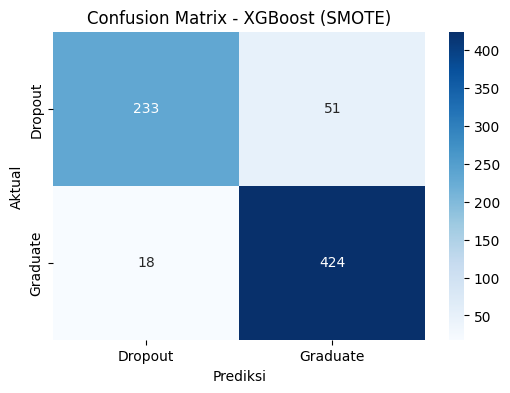

Model XGBoost terbaik telah disimpan sebagai 'best_model.pkl'


In [5]:
print("=== Performa Random Forest ===")
print(classification_report(y_test, rf_pred, target_names=le.classes_))

print("\n=== Performa XGBoost (Terbaik) ===")
print(classification_report(y_test, xgb_pred, target_names=le.classes_))

# Visualisasi Confusion Matrix XGBoost
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, xgb_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - XGBoost (SMOTE)')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()

# Export Model Terbaik
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)
print("Model XGBoost terbaik telah disimpan sebagai 'best_model.pkl'")

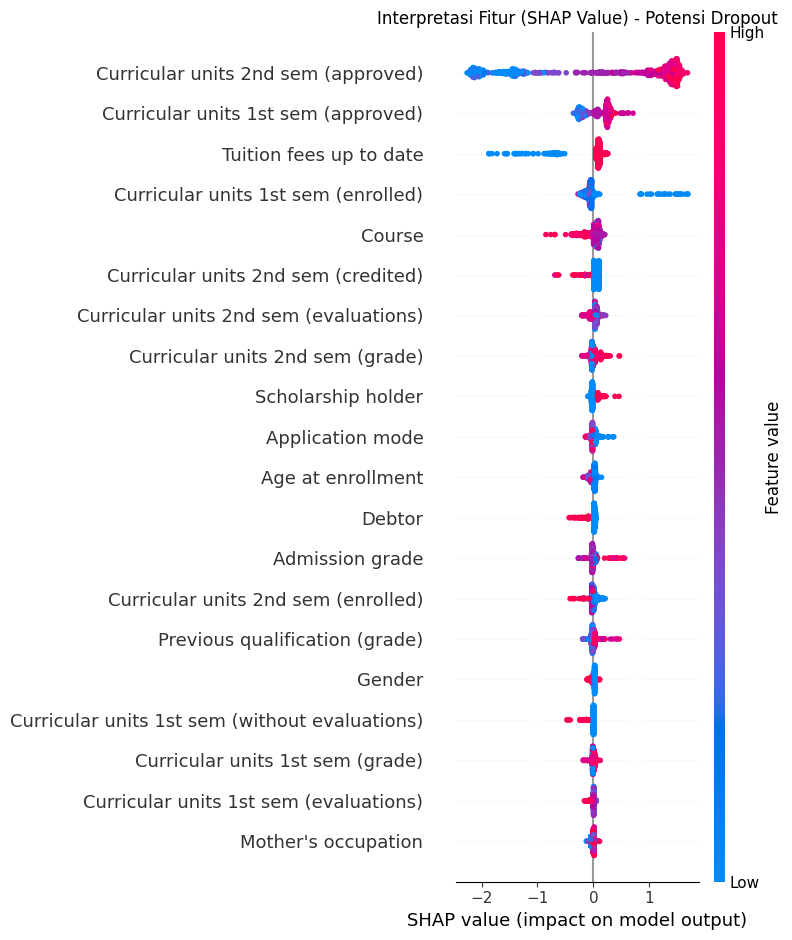

In [6]:
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(8,6))
shap.summary_plot(shap_values, X_test, feature_names=X.columns, show=False)
plt.title('Interpretasi Fitur (SHAP Value) - Potensi Dropout')
plt.tight_layout()
plt.show()